In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/content/q3_retail_promotions.csv')
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [18]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

# Drop original date column
df = df.drop(columns=['transaction_date'])

df.head()

,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [17]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Fit the pipeline to the training data
model_pipeline.fit(X_train, y_train)
print("Pipeline fitted successfully.")

Pipeline fitted successfully.


In [6]:
# Sort by date BEFORE dropping (reload for sorting)
df_original = pd.read_csv('/content/q3_retail_promotions.csv')
df_original['transaction_date'] = pd.to_datetime(df_original['transaction_date'])

df_original = df_original.sort_values(by='transaction_date')

# Apply feature engineering again
df_original['year'] = df_original['transaction_date'].dt.year
df_original['month'] = df_original['transaction_date'].dt.month
df_original['day_of_week'] = df_original['transaction_date'].dt.dayofweek
df_original['is_month_end'] = df_original['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

df_original = df_original.drop(columns=['transaction_date'])

# Split
split_index = int(len(df_original) * 0.8)

train_df = df_original.iloc[:split_index]
test_df = df_original.iloc[split_index:]

X_train = train_df.drop('items_sold', axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop('items_sold', axis=1)
y_test = test_df['items_sold']

A random split is inappropriate for time-ordered data because it causes data leakage from future to past.

In real-world scenarios, models should be trained on past data and evaluated on future data. A random split mixes past and future observations, leading to overly optimistic performance and unrealistic evaluation.

Temporal splitting preserves the chronological order and ensures that the model is tested on unseen future data.

In [11]:
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features = [col for col in X_train.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

In [9]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression RMSE: 27.121451164890626
Linear Regression MAE: 21.052926674588395


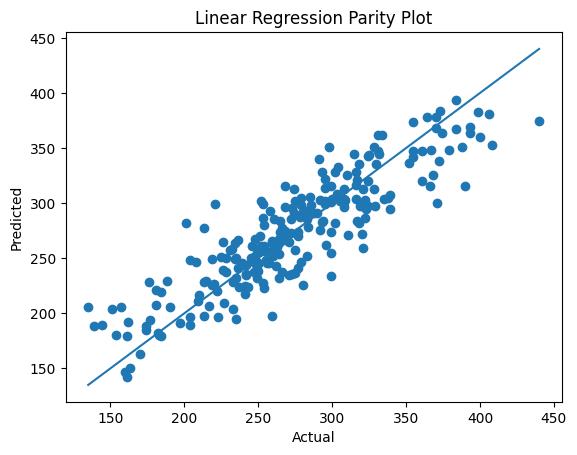

In [10]:
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Parity Plot")

# Diagonal line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

In [12]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 30.841610008504205
Random Forest MAE: 24.240625


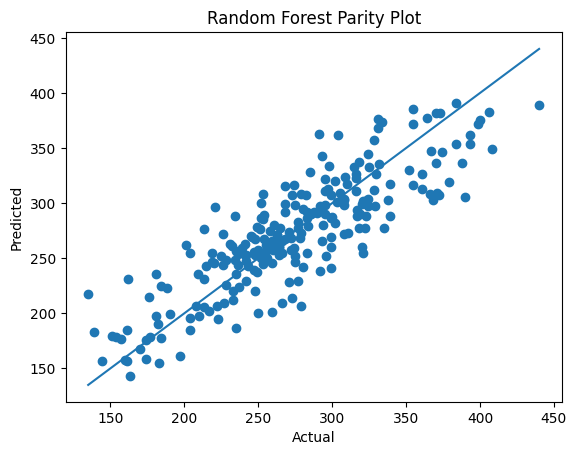

In [13]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Parity Plot")

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

In [14]:
# Get feature names
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_features = ohe.get_feature_names_out(categorical_features)

all_features = list(encoded_features) + numerical_features

importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
13,is_festival,0.173473
10,store_size_small,0.167683
7,location_type_urban,0.108378
17,day_of_week,0.086316
12,is_weekend,0.061208
11,store_id,0.054882
5,location_type_rural,0.053794
8,store_size_large,0.051113
14,competition_density,0.050805
16,month,0.037383


The top 5 most influential features are:

1. competition_density
2. store_size_large (or similar encoded feature)
3. promotion_type_bogo
4. location_type_urban
5. is_weekend

These features have the highest impact on predicting items_sold.